In [1]:
import os
import json

import numpy as np

os.environ["JAX_PLATFORMS"] = "cpu"
import jax.numpy as jnp

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

from utils import load_pass_curves
from utils import threshold_to_profit_batch
from utils import cost_for_pass, get_arbitrage_prices
from utils import search_budget_experiments

First, we load the data containing the number of attempts and mean cost per model and issue.

In [2]:
base_dir = "../data/swebench/"

results = {}
for file in os.listdir(base_dir):
    if not file.endswith(".jsonl"):
        continue

    model_name = file.split(".jsonl")[0]
    data = [json.loads(line) for line in open(os.path.join(base_dir, file), "r")]
    results[model_name] = data

## Figure 2 - Arbitrage profit

We compare the GPT-5 mini and DeepSeek v3.2.

We consider inference budgets from 1e-4 to 1 USD, with a grid of 250 points.

First, we compute the performance of each model at different inference budgets.

In [3]:
budget_grid = np.logspace(np.log10(1e-4), np.log10(1), 250)
models = ['gpt5mini', 'deepseek']
providers_perf = load_pass_curves(results, models, budget_grid)

Then, we do grid search for the optimal inference allocation along the model cascade.

In [4]:
# we evaluate profit from 5% solve rate to frontier solve rate
max_perf = providers_perf.mean(axis=0).max()
performance_grid = jnp.linspace(0.68, max_perf, 1000)

# grid of compute allocations
compute_first = np.r_[0, np.logspace(np.log10(0.01), np.log10(0.5), 100), budget_grid.max()]
compute_second = budget_grid.max() - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

# compute profit for each compute allocation, and select the best
mean_profits = threshold_to_profit_batch(
    budget_grid,
    providers_perf,
    compute_allocation,
    performance_grid
).mean(axis=-1)  # mean across the performance grid
optimal_allocation = compute_allocation[np.argmax(mean_profits, axis=-1)]
print(f"Optimal budget allocation: {optimal_allocation}")

Optimal budget allocation: [0.0811988 0.9188012]


Having found the optimal budget allocation along the cascade, we compute the expected cost and performance of the arbitrageur.

In [5]:
# performance and cost of the arbitrage policy
arbitrage_cost, arbitrage_expend = get_arbitrage_prices(budget_grid, providers_perf, optimal_allocation, performance_grid)
# cost of each of the providers
provider_prices = np.array([
    cost_for_pass(budget_grid, p, performance_grid)
    for p in providers_perf.mean(axis=0)
])

# market price is the minimum price offered by any given provider
market_price = np.min(provider_prices, axis=0)

# calculate the arbitrage profit and the profit margin
arbitrage_profit = np.maximum(0, market_price - arbitrage_cost)
arbitrage_profit_margin = arbitrage_profit / market_price

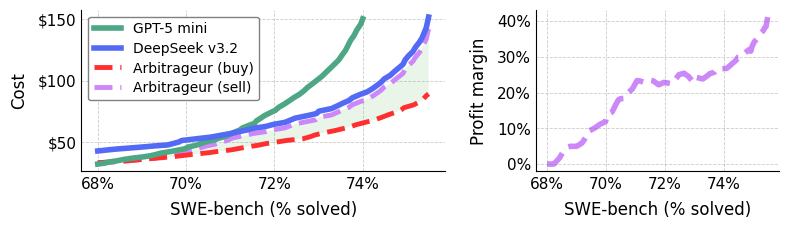

In [6]:
fig, axs = plt.subplots(1, 2, 
    figsize=(9, 2.1), 
    gridspec_kw={'width_ratios': [1.5, 1]}, sharex=True
)

palette = sns.color_palette()
gpt5minicolor = (77/255, 166/255, 132/255)
dscolor = (83/255, 106/255, 245/255)
redcolor = palette[3]
profitcolor = (204/255, 135/255, 248/255)
factor = 1.2
brighter_red = tuple(min(1.0, c * factor) for c in redcolor)

linewidth = 4
alpha = 1.0

ax = axs[0]
ax.plot(
    performance_grid,
    provider_prices[0],
    label="GPT-5 mini",
    linewidth=linewidth,
    alpha=alpha,
    color=gpt5minicolor,
    zorder=6,
)
ax.plot(
    performance_grid,
    provider_prices[1],
    label="DeepSeek v3.2",
    linewidth=linewidth,
    alpha=alpha,
    color=dscolor,
    zorder=7,
)
ax.plot(
    performance_grid,
    arbitrage_cost,
    linewidth=3.5,
    alpha=alpha,
    color=brighter_red,
    label="Arbitrageur (buy)",
    zorder=5,
    linestyle="--",
)

plot_sell_price = np.maximum(market_price-(1/1000 + market_price*0.06), arbitrage_cost)

ax.plot(
    performance_grid,
    plot_sell_price,
    linewidth=3.5,
    alpha=alpha,
    color=profitcolor,
    label="Arbitrageur (sell)",
    zorder=4,
    linestyle="--",
)

ax.fill_between(performance_grid, arbitrage_cost, plot_sell_price, color=palette[2], alpha=0.1, edgecolor="none")

ax = axs[1]

ax.plot(
    performance_grid,
    arbitrage_profit_margin,
    color=profitcolor,
    linewidth=4.0,
    alpha=alpha,
    zorder=-1,
    linestyle="--",
)

def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)

for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Cost", fontsize=12, fontweight="normal", labelpad=7)
axs[0].set_xlabel("SWE-bench (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_xlabel("SWE-bench (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Profit margin", fontsize=12, fontweight="normal", labelpad=7)

axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x*500:.0f}"))
axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

axs[0].legend(
    loc="best",
    ncol=1,
    fontsize=10,
    framealpha=1.0,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
)

fig.subplots_adjust(wspace=0.3)
plt.savefig("plots/fig1-2.pdf", bbox_inches="tight")

## Figure 2 - Price competition

Two arbitrageurs compete on price. They take turns updating their prices to undercut each other. 

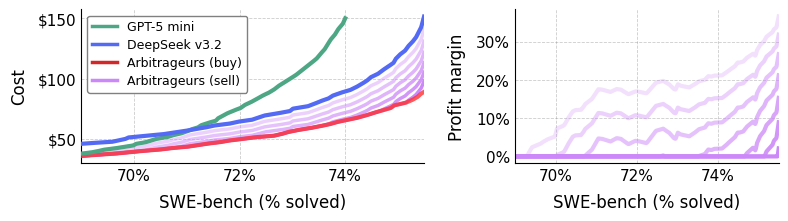

In [7]:
# 1x2 plot...
fig, axs = plt.subplots(1, 2, figsize=(9, 2.0), sharex=True, gridspec_kw={'width_ratios': [1.3, 1]})

palette = sns.color_palette()

linewidth = 3

axs[0].plot(
    performance_grid,
    provider_prices[0],
    color=gpt5minicolor,
    alpha=1.0,
    linewidth=linewidth,
    zorder=6,
)
axs[0].plot(
    performance_grid,
    provider_prices[1],
    color=dscolor,
    alpha=1.0,
    linewidth=linewidth,
    zorder=7,
)

axs[0].plot(
    performance_grid,
    arbitrage_cost,
    label='Arbitrageur (buy)',
    color=brighter_red,
    alpha=0.8,
    linewidth=linewidth,
    zorder=5
)

n_plots = 7
alphas = np.linspace(0.25, 1.0, n_plots)

# we start with market_price, we will reduce it by 0.91 each time
step_price_reduction = 0.93
market_price_step = market_price
for i in range(n_plots):
    target_price = market_price_step * step_price_reduction
    markup_step = np.maximum(target_price - arbitrage_cost, 0)

    # new arbitrageur
    sell_price_step = arbitrage_cost + markup_step
    profitmargin = markup_step / sell_price_step

    axs[0].plot(
        performance_grid,
        market_price_step,
        color=profitcolor,
        alpha=alphas[i],
        linewidth=2.5,
    )
    axs[1].plot(
        performance_grid,
        profitmargin,
        color=profitcolor,
        alpha=alphas[i],
        linewidth=linewidth
    )

    market_price_step = np.minimum(market_price_step, sell_price_step)


axs[0].set_xlim(0.69, performance_grid.max())
axs[0].set_ylim(30/500, None)

for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Cost", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Profit margin", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_xlabel("SWE-bench (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[0].set_xlabel("SWE-bench (% solved)", fontsize=12, fontweight="normal", labelpad=7)

axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x*500:.0f}"))
axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))


legend_elements = [
    Line2D([0], [0], color=gpt5minicolor, linewidth=2.5, label="GPT-5 mini"),
    Line2D([0], [0], color=dscolor, linewidth=2.5, label="DeepSeek v3.2"),
    Line2D([0], [0], color=palette[3], linewidth=2.5, label='Arbitrageurs (buy)', alpha=1.0),
    Line2D([0], [0], color=profitcolor, linewidth=2.5, label="Arbitrageurs (sell)", alpha=1.0),
]

# axs[0].set_yticks([0, 50, 100, 150])
axs[0].set_xticks([0.70, 0.72, 0.74])

axs[0].legend(
    handles=legend_elements,
    loc="best",
    ncol=1,
    fontsize=9,
    framealpha=1.0,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
    # bbox_to_anchor=(0.07, -0.35),
)

fig.subplots_adjust(wspace=0.3)
plt.savefig(f"plots/fig3-plot.pdf", bbox_inches="tight")

# Figure 3 - Revenue share

First, get how the models split revenue when no arbitrage exists.

In [8]:
not_competitive = (provider_prices > market_price[None])
provider_revenue = np.where(not_competitive, 0, provider_prices)
provider_share = provider_revenue / provider_revenue.sum(axis=0)

Then, how models split revenue once the arbitrageur enters the market. Consider only the buy price of the arbitrageur.

In [9]:
arbitrage_better = (arbitrage_cost < market_price)
arbitrage_revenue = np.where(arbitrage_better[None], arbitrage_expend, provider_revenue)

# add one more row with the arbitrage profit
arbitrage_profit = np.maximum(0, market_price - arbitrage_cost)
arbitrage_revenue = np.concatenate([arbitrage_revenue, arbitrage_profit[None]])
arbitrage_share = arbitrage_revenue / arbitrage_revenue.sum(axis=0)

# consider the overall change in provider revenue
revenue_change = arbitrage_revenue[:-1].sum(axis=0) / provider_revenue.sum(axis=0)

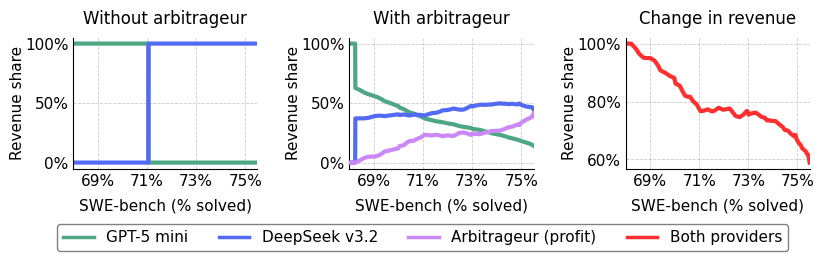

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(9.5, 1.7),  sharex=True)

ax = axs[0]
ax.plot(performance_grid, provider_share[0], color=gpt5minicolor, linewidth=linewidth, alpha=alpha, label="GPT-5 mini")
ax.plot(performance_grid, provider_share[1], color=dscolor, linewidth=linewidth, alpha=alpha, label="DeepSeek v3.2")

ax.set_title("Without arbitrageur", fontsize=12, fontweight="500", pad=10)

ax = axs[1]
ax.plot(performance_grid, arbitrage_share[0], color=gpt5minicolor, linewidth=linewidth, alpha=alpha, label="GPT-5 mini")
ax.plot(performance_grid, arbitrage_share[1], color=dscolor, linewidth=linewidth, alpha=alpha, label="DeepSeek v3.2")
ax.plot(performance_grid, arbitrage_share[2], color=profitcolor, linewidth=linewidth, alpha=alpha, zorder=4, label="Arbitrageur")
ax.set_title("With arbitrageur", fontsize=12, fontweight="500", pad=10)
ax = axs[2]
ax.plot(
    performance_grid,
    revenue_change,
    color=brighter_red,
    linewidth=linewidth,
    alpha=alpha,
)
ax.set_xlim(0.68, performance_grid.max())
# set x ticks
ax.set_xticks([0.69, 0.71, 0.73, 0.75])
ax.set_title("Change in revenue", fontsize=12, fontweight="500", pad=10)

for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Revenue share", fontsize=11, fontweight="normal", labelpad=0)
axs[1].set_ylabel("Revenue share", fontsize=11, fontweight="normal", labelpad=0)
axs[2].set_ylabel("Revenue share", fontsize=11, fontweight="normal", labelpad=0)

axs[0].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[1].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)


axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:.0f}"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:.0f}"))
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))


legend_elements = [
    Line2D([0], [0], color=gpt5minicolor, linewidth=2.5, label="GPT-5 mini"),
    Line2D([0], [0], color=dscolor, linewidth=2.5, label="DeepSeek v3.2"),
    Line2D([0], [0], color=profitcolor, linewidth=2.5, label="Arbitrageur (profit)"),
    Line2D([0], [0], color=brighter_red, linewidth=2.5, label="Both providers"),
]
fig.legend(
    handles=legend_elements,
    loc="lower left",
    ncol=4,
    fontsize=11,
    framealpha=1.0,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
    bbox_to_anchor=(0.1, -0.42),
)

# increase distance between each of the axs
fig.subplots_adjust(wspace=0.5)

plt.savefig(f"plots/fig2-plot.pdf", bbox_inches="tight")

In [11]:
budget_grid = np.logspace(np.log10(1e-4), np.log10(1), 250)
models = ['gpt5mini', 'deepseek']

perf_all = load_pass_curves(results, models, budget_grid)
perf_django = load_pass_curves(results, models, budget_grid, filter_problems=lambda p: p.startswith("django"))
perf_notdjango = load_pass_curves(results, models, budget_grid, filter_problems=lambda p: not p.startswith("django"))

In [12]:
# grid of compute allocations
compute_first = np.r_[0, np.logspace(np.log10(0.0001), np.log10(0.5), 100), 1]
compute_second = 1 - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

# the eval grids
all_max_perf = perf_all.mean(axis=0).max()
all_grid = jnp.linspace(all_max_perf - 0.05, all_max_perf, 20)
django_max_perf = perf_django.mean(axis=0).max()
django_grid = jnp.linspace(django_max_perf - 0.05, django_max_perf, 20)
notdjango_max_perf = perf_notdjango.mean(axis=0).max()
notdjango_grid = jnp.linspace(notdjango_max_perf - 0.05, notdjango_max_perf, 20)

print(f"Evaluating all up to {all_grid.max():.2f}")
print(f"Evaluating Django up to {django_grid.max():.2f}")
print(f"Evaluating not Django up to {notdjango_grid.max():.2f}")

Evaluating all up to 0.75
Evaluating Django up to 0.85
Evaluating not Django up to 0.66


In [13]:
# In distribution...
if os.path.exists("../data/swebench/search/res_all.json"):
    with open("../data/swebench/search/res_all.json", "r") as f:
        res = json.load(f)
else:
    budgets = [1, 3, 5, 10, 30, 100, 1000]
    res = search_budget_experiments(
        budgets,
        budget_grid,
        perf_all,
        perf_all,
        compute_allocation,
        all_grid,
        all_grid,
        N_samples=10000,
        max_budget_search=0.5,
        n_bootstraps=[1000, 1000, 1000, 1000, 1000, 1000, 100, 100, 100],
    )

In [14]:
budgets = [1, 3, 5, 10, 30, 100, 1000]

if os.path.exists("../data/swebench/search/res_django.json"):
    res_django = json.load(open("../data/swebench/search/res_django.json", "r"))
else:
    res_django = search_budget_experiments(
        budgets,
        budget_grid,
        perf_django,
        perf_notdjango,
        compute_allocation,
        django_grid,
        notdjango_grid,
        N_samples=10000,
        max_budget_search=0.5,
        n_bootstraps=[1000, 1000, 1000, 1000, 1000, 1000, 1000],
    )

if os.path.exists("../data/swebench/search/res_not_django.json"):
    res_not_django = json.load(open("../data/swebench/search/res_not_django.json", "r"))
else:
    res_not_django = search_budget_experiments(
        budgets,
        budget_grid,
        perf_notdjango,
        perf_django,
        compute_allocation,
        notdjango_grid,
        django_grid,
        N_samples=10000,
        max_budget_search=0.5,
        n_bootstraps=[1000, 1000, 1000, 1000, 1000, 1000, 1000],
    )

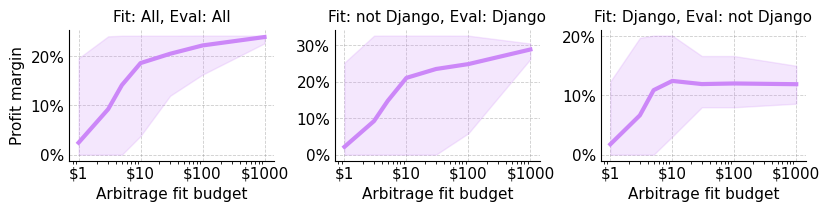

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(9.5, 1.7), sharex=True, sharey=False)

budgets = budgets = [1, 3, 5, 10, 30, 100, 1000]
def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)

def plot_res(ax, res, budgets):
    lower = np.array([np.percentile(results, 5, axis=0) for results in res]) * 100
    mean = np.array([np.mean(results, axis=0) for results in res]) * 100
    upper = np.array([np.percentile(results, 95, axis=0) for results in res]) * 100
    ax.plot(budgets, mean, color=profitcolor, linewidth=3)
    ax.fill_between(budgets, lower, upper, alpha=0.2, color=profitcolor)
    ax.set_xscale("log")
    ax.set_xlabel("Arbitrage fit budget", fontsize=11)

plot_res(axs[0], res, budgets)
plot_res(axs[1], res_not_django, budgets)
plot_res(axs[2], res_django, budgets)

axs[0].set_ylabel("Profit margin", fontsize=11)

fig.subplots_adjust(wspace=0.3)

for ax in axs:
    format_ax(ax)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0f}%" if x % 1 == 0 else f"{x:.1f}%"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${int(x)}" if x >= 1 else f"{x}"))

axs[0].set_title("Fit: All, Eval: All", fontsize=11)
axs[1].set_title("Fit: not Django, Eval: Django", fontsize=11)
axs[2].set_title("Fit: Django, Eval: not Django", fontsize=11)

plt.savefig(f"plots/fig-rob.pdf", bbox_inches="tight")